In [ ]:
PROJ_NAME = "kyber_indcca_dec_ttest"
LABEL = ""
PRNG_OFF = False
N = 100000
OFFSET_ARR = [0, 120000, 240000, 360000, 480000]

In [11]:
import sys
sys.path.insert(0, "../")
from host import ttest_trace_collector
%matplotlib widget

In [12]:
trace_collector_arr = [ttest_trace_collector.TTestTraceCollector(proj_name=PROJ_NAME, label=LABEL, offset=offset) for offset in OFFSET_ARR]

In [13]:
ttest_analysis_arr = [trace_collector.get_analysis_obj(N=N, prng_off=PRNG_OFF) for trace_collector in trace_collector_arr]

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_indcca_dec_ttest_N1000_prngoff1_r0_o0_.ets with 1000 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_indcca_dec_ttest_N1000_prngoff1_r1_o0_.ets with 1000 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_indcca_dec_ttest_N1000_prngoff1_r0_o120000_.ets with 1000 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_indcca_dec_ttest_N1000_prngoff1_r1_o120000_.ets with 1000 traces.
s................: float64

Trace Header Set:
Name.............: ETS Format THS
Reader...........: ETS format reader of file traces/kyber_indcca_dec_ttest_N1000_prngoff1_r0_o240000_.ets with 1000 traces.
s................:

In [14]:
for ttest_analysis in ttest_analysis_arr:
    ttest_analysis.load_ttest_results()


In [15]:
import numpy as np

for i in range(1, len(ttest_analysis_arr)):
    ttest_analysis_arr[0].mean_trace_1 = np.concatenate((ttest_analysis_arr[0].mean_trace_1, ttest_analysis_arr[i].mean_trace_1), axis=0)
    ttest_analysis_arr[0].mean_trace_0 = np.concatenate((ttest_analysis_arr[0].mean_trace_0, ttest_analysis_arr[i].mean_trace_0), axis=0)


/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


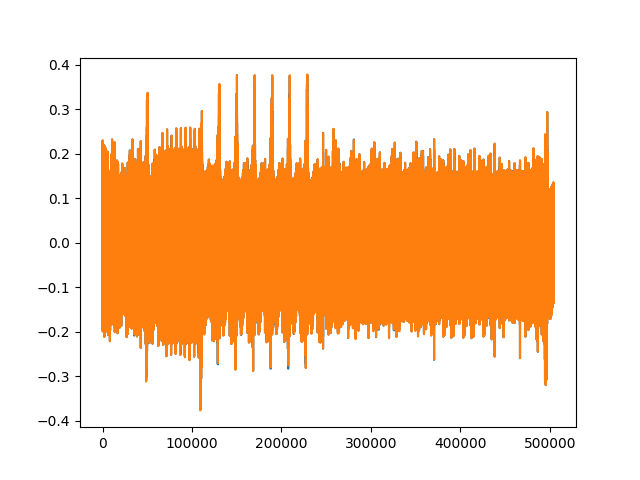

In [16]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()
ax.plot(ttest_analysis_arr[0].mean_trace_1, label="Mean Trace 1")
ax.plot(ttest_analysis_arr[0].mean_trace_0, label="Mean Trace 0")

In [17]:
for i in range(1, len(ttest_analysis_arr)):
    ttest_analysis_arr[0].ttest.result = np.concatenate((ttest_analysis_arr[0].ttest.result, ttest_analysis_arr[i].ttest.result), axis=0)
   

/home/toluntosun/miniconda3/envs/sca/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


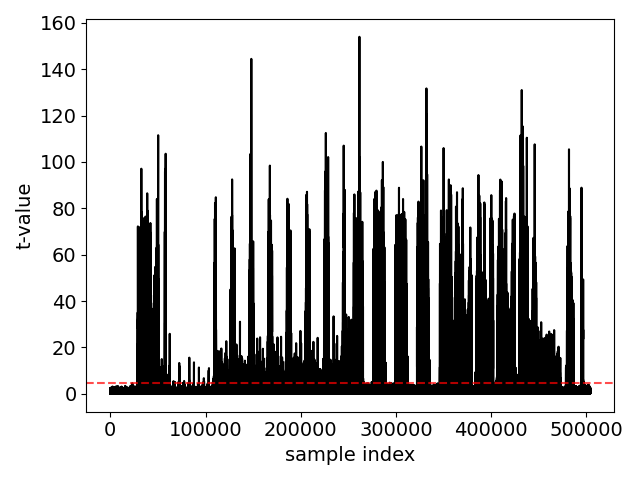

In [20]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots()
ttest_analysis_arr[0].plot_ttest(ax=ax, color='black', plt_show=False, put_title=False, put_label=True, label_fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
fig.tight_layout()